Using Colab cache for faster access to the 'housing-prices-dataset' dataset.
Dataset path: /kaggle/input/housing-prices-dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


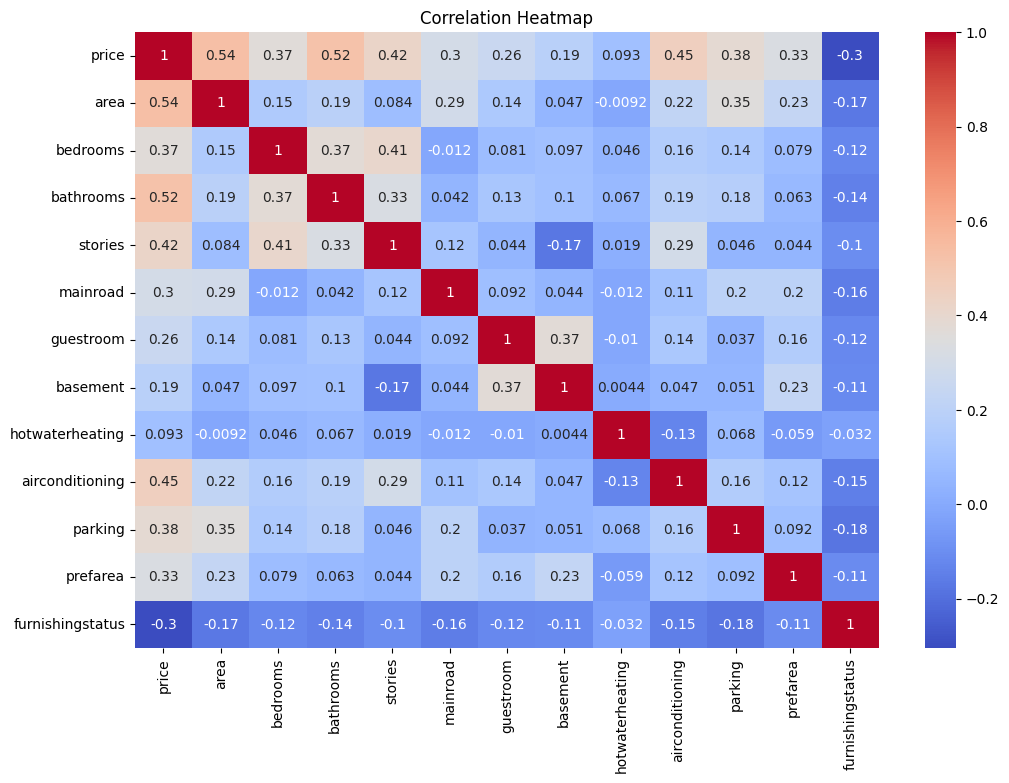

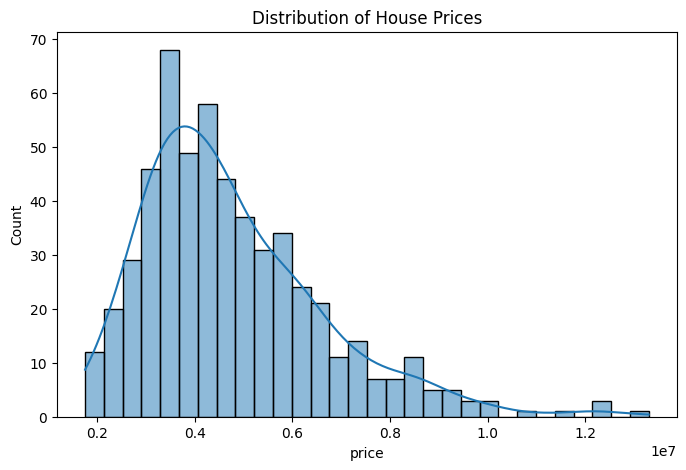

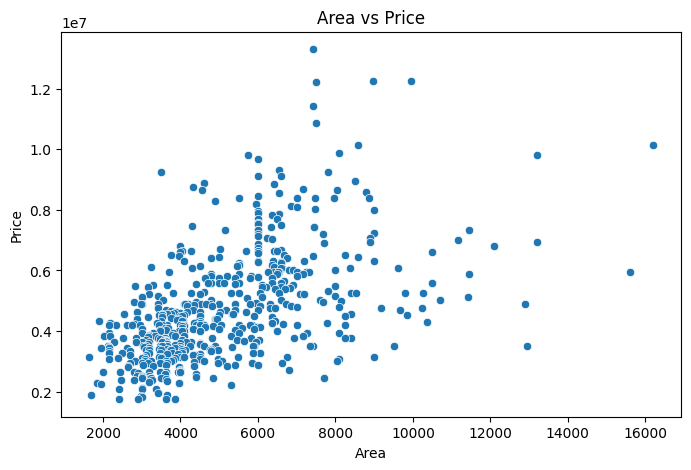

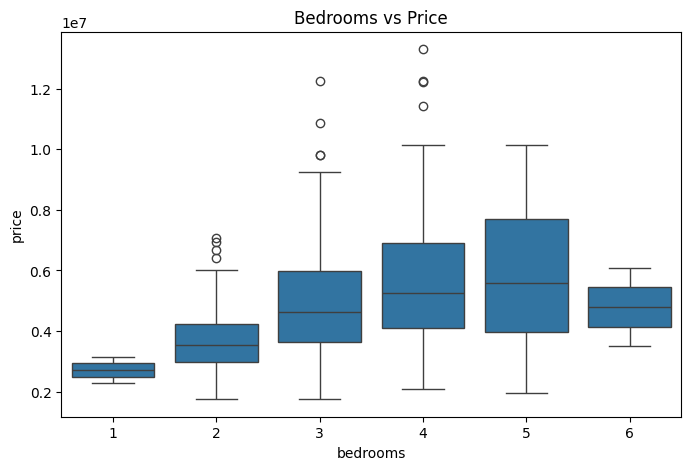

Linear Regression MSE: 1771751116594.0352
Linear Regression R2 Score: 0.6494754192267803
Random Forest MSE: 1963538216518.6526
Random Forest R2 Score: 0.6115321143409216


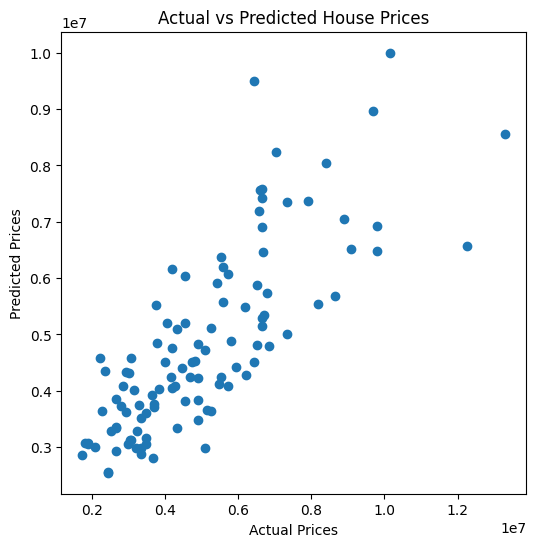

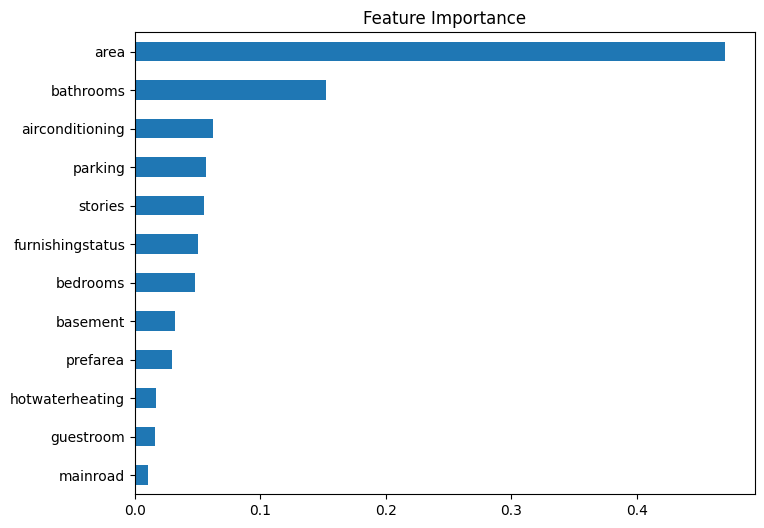

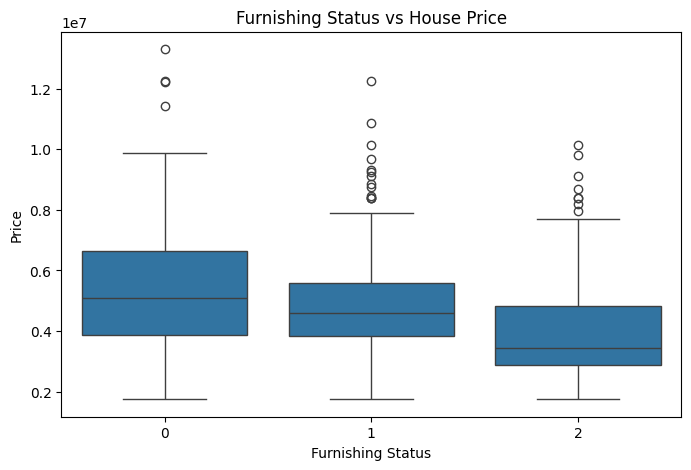

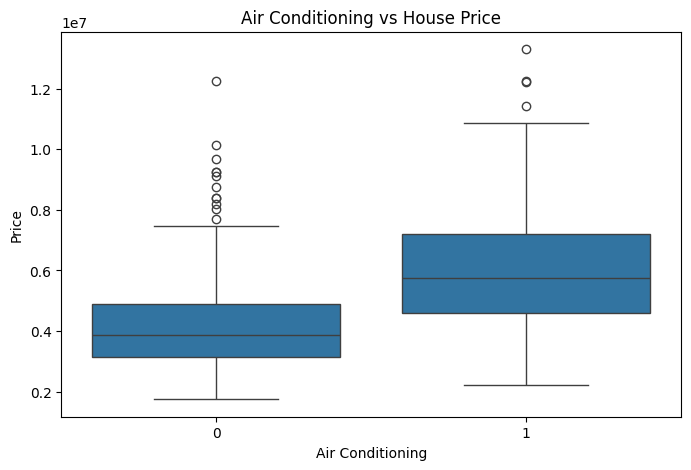

Predicted Price: 6738123.608690672
   area  bedrooms  bathrooms  stories  mainroad  guestroom  basement  \
0  4000         3          2        2         1          0         0   
1  6000         4          3        2         1          1         1   
2  8000         5          4        3         1          1         1   

   hotwaterheating  airconditioning  parking  prefarea  furnishingstatus  \
0                0                1        1         1                 1   
1                0                1        2         1                 2   
2                0                1        3         1                 0   

   Predicted Price  
0     6.276518e+06  
1     8.565574e+06  
2     1.126574e+07  


In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

import kagglehub
import os

# Download dataset
path = kagglehub.dataset_download("yasserh/housing-prices-dataset")

print("Dataset path:", path)

# See files in folder
os.listdir(path)

df = pd.read_csv(path + "/Housing.csv")

df.head()
df.shape
df.columns

#Checking Dataset Information like data type no of enteties so on
df.info()
df.describe()
#Checking Missing Values:To check if any values are missing.
df.isnull().sum()

#checking and converting into numeric value  0 and 1 me
df.select_dtypes(include='object').columns

le = LabelEncoder()

categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])
df.head()

#eda analyse karne ke liye
#Shows correlation between all variables

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

 #Price Distribution

plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=30, kde=True)
plt.title("Distribution of House Prices")
plt.show()

#Area vs Price

plt.figure(figsize=(8,5))
sns.scatterplot(x=df['area'], y=df['price'])
plt.title("Area vs Price")
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()

#boxplot

plt.figure(figsize=(8,5))
sns.boxplot(x=df['bedrooms'], y=df['price'])
plt.title("Bedrooms vs Price")
plt.show()

#targeting price
X = df.drop("price", axis=1)
y = df["price"]


#split Dataset

#We split data into:

#Training data (80%)
#Testing data (20%)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Train Linear Regression Model
lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

#Train Random Forest Model

rf = RandomForestRegressor(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

#Model Evaluation
#Linear Regression

mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression MSE:", mse_lr)
print("Linear Regression R2 Score:", r2_lr)

#random for4st

mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest MSE:", mse_rf)
print("Random Forest R2 Score:", r2_rf)


#Actual vs Predicted Graph to see how acurate our model is

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")

plt.show()

#Feature Importance  Calculates how important each feature is.

importance = rf.feature_importances_

features = pd.Series(importance, index=X.columns)

features.sort_values().plot(kind='barh', figsize=(8,6))

plt.title("Feature Importance")
plt.show()

#Furnishing Status vs Price (Boxplot)
plt.figure(figsize=(8,5))

sns.boxplot(x='furnishingstatus', y='price', data=df)

plt.title("Furnishing Status vs House Price")
plt.xlabel("Furnishing Status")
plt.ylabel("Price")

plt.show()

#Air Conditioning vs Price
plt.figure(figsize=(8,5))

sns.boxplot(x='airconditioning', y='price', data=df)

plt.title("Air Conditioning vs House Price")
plt.xlabel("Air Conditioning")
plt.ylabel("Price")

plt.show()

# checking with data set
new_house = pd.DataFrame({
    'area':[5000],
    'bedrooms':[3],
    'bathrooms':[2],
    'stories':[2],
    'mainroad':[1],
    'guestroom':[0],
    'basement':[0],
    'hotwaterheating':[0],
    'airconditioning':[1],
    'parking':[2],
    'prefarea':[1],
    'furnishingstatus':[1]
})

prediction = lr.predict(new_house)

print("Predicted Price:", prediction[0])

new_houses = pd.DataFrame({
    'area': [4000, 6000, 8000],
    'bedrooms': [3, 4, 5],
    'bathrooms': [2, 3, 4],
    'stories': [2, 2, 3],
    'mainroad': [1, 1, 1],
    'guestroom': [0, 1, 1],
    'basement': [0, 1, 1],
    'hotwaterheating': [0, 0, 0],
    'airconditioning': [1, 1, 1],
    'parking': [1, 2, 3],
    'prefarea': [1, 1, 1],
    'furnishingstatus': [1, 2, 0]
})

predictions = lr.predict(new_houses)

new_houses['Predicted Price'] = predictions

print(new_houses)

